In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 中文显示（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/retail_cleaned.csv", parse_dates=["InvoiceDate"])
print(f"数据量：{len(df):,} 行")

数据量：805,549 行


## 1. 时间维度：月度销售趋势

<local-temp>\2295749249.py:20: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
<local-temp>\pylabtools.py:170: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


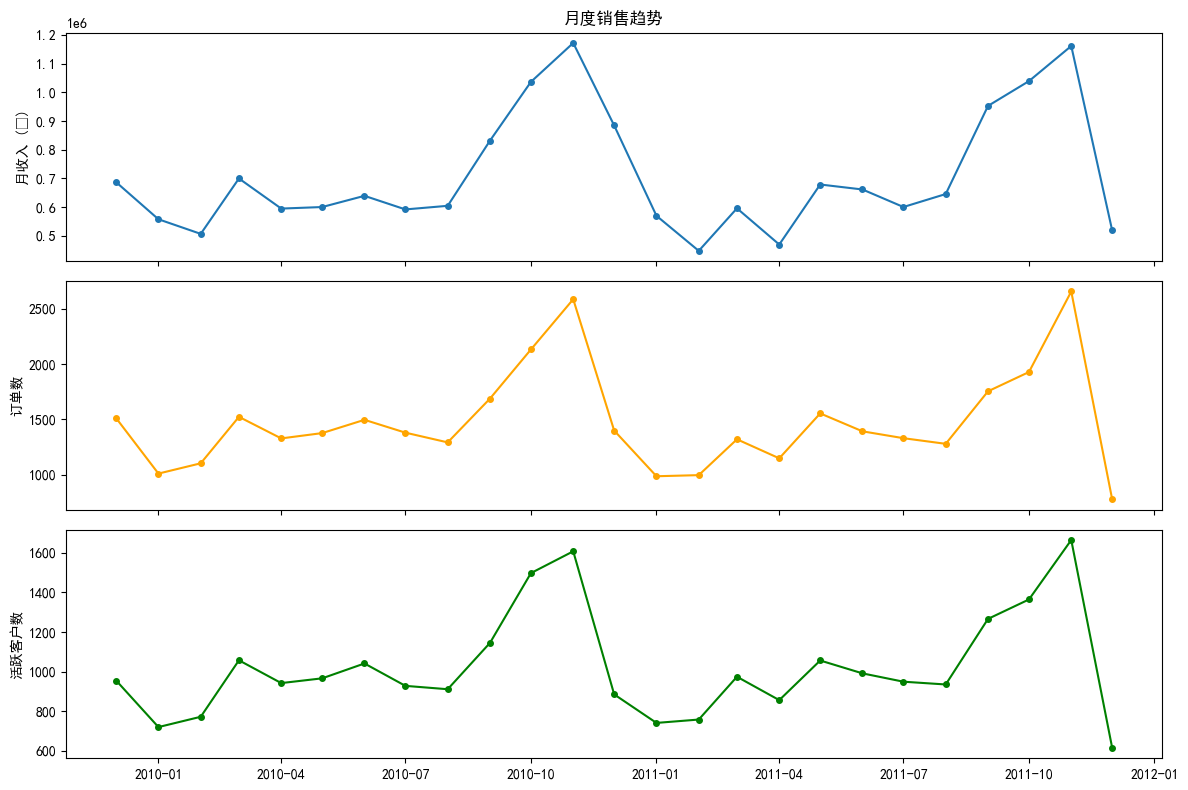

In [2]:
monthly = df.groupby(df["InvoiceDate"].dt.to_period("M")).agg(
    收入=("Revenue", "sum"),
    订单数=("Invoice", "nunique"),
    客户数=("Customer ID", "nunique")
)
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly.index, monthly["收入"], marker="o", markersize=4)
axes[0].set_ylabel("月收入 (£)")
axes[0].set_title("月度销售趋势")

axes[1].plot(monthly.index, monthly["订单数"], marker="o", markersize=4, color="orange")
axes[1].set_ylabel("订单数")

axes[2].plot(monthly.index, monthly["客户数"], marker="o", markersize=4, color="green")
axes[2].set_ylabel("活跃客户数")

plt.tight_layout()
plt.show()

## 发现：明显的季节性规律
- 每年 9-11 月销售额大幅攀升（圣诞采购季），11月达到峰值
- 12月骤降（数据集截止于12月初，并非真实下降）
- 年度对比：2011年整体高于2010年，业务在增长

## 2. 地域维度：各国销售分布

In [3]:
country = df.groupby("Country").agg(
    收入=("Revenue", "sum"),
    客户数=("Customer ID", "nunique"),
    订单数=("Invoice", "nunique")
).sort_values("收入", ascending=False)

print("Top 10 市场：")
print(country.head(10).to_string())
print(f"\n英国占比：{country.loc['United Kingdom', '收入'] / country['收入'].sum():.1%}")

Top 10 市场：
                          收入   客户数    订单数
Country                                  
United Kingdom  1.472315e+07  5350  33541
EIRE            6.216311e+05     5    567
Netherlands     5.542323e+05    22    228
Germany         4.312625e+05   107    789
France          3.552575e+05    95    614
Australia       1.699681e+05    15     95
Spain           1.091785e+05    41    154
Switzerland     1.003653e+05    22     90
Sweden          9.154972e+04    19    104
Denmark         6.986219e+04    12     43

英国占比：83.0%


## 发现：高度集中的单一市场
- 英国贡献 83% 收入，5,350 个客户（占总客户 91%）
- 海外市场零散，爱尔兰第二但只有 5 个客户（可能是大客户/批发商）
- **产品启示**：海外扩张有空间，但需要先搞清楚海外客户是零售还是批发

## 3. 商品维度：热销商品与长尾分布

In [4]:
product = df.groupby("Description").agg(
    收入=("Revenue", "sum"),
    销量=("Quantity", "sum"),
    购买人数=("Customer ID", "nunique")
).sort_values("收入", ascending=False)

print("收入 Top 10 商品：")
print(product.head(10).to_string())

# 验证二八法则
total_revenue = product["收入"].sum()
product_cumsum = product["收入"].cumsum() / total_revenue
top_20_pct = int(len(product) * 0.2)
print(f"\n前 20% 商品（{top_20_pct} 个）贡献了 {product_cumsum.iloc[top_20_pct]:.1%} 的收入")

收入 Top 10 商品：
                                           收入     销量  购买人数
Description                                               
REGENCY CAKESTAND 3 TIER            286486.30  24899  1314
WHITE HANGING HEART T-LIGHT HOLDER  252072.46  93640  1490
PAPER CRAFT , LITTLE BIRDIE         168469.60  80995     1
Manual                              152340.57   9803   438
JUMBO BAG RED RETROSPOT             136980.08  75759   860
ASSORTED COLOUR BIRD ORNAMENT       127074.17  79913  1010
POSTAGE                             126563.04   5333   405
PARTY BUNTING                       103880.23  23607   894
MEDIUM CERAMIC TOP STORAGE JAR       81416.73  77916   138
PAPER CHAIN KIT 50'S CHRISTMAS       79594.33  29477   896

前 20% 商品（1056 个）贡献了 78.4% 的收入


## 发现：商品长尾效应显著
- 前 20% 商品贡献 78.4% 收入，接近二八法则
- "PAPER CRAFT, LITTLE BIRDIE" 只有 1 个购买人但销量 8 万+，明显是批发大客户
- "POSTAGE" 和 "Manual" 不是真实商品，是运费和手工调整项
- **产品启示**：热销商品集中度高，推荐系统应重点围绕 Top 商品做交叉推荐；同时需要区分零售和批发场景

## 4. 用户维度：购买频次与消费额分布

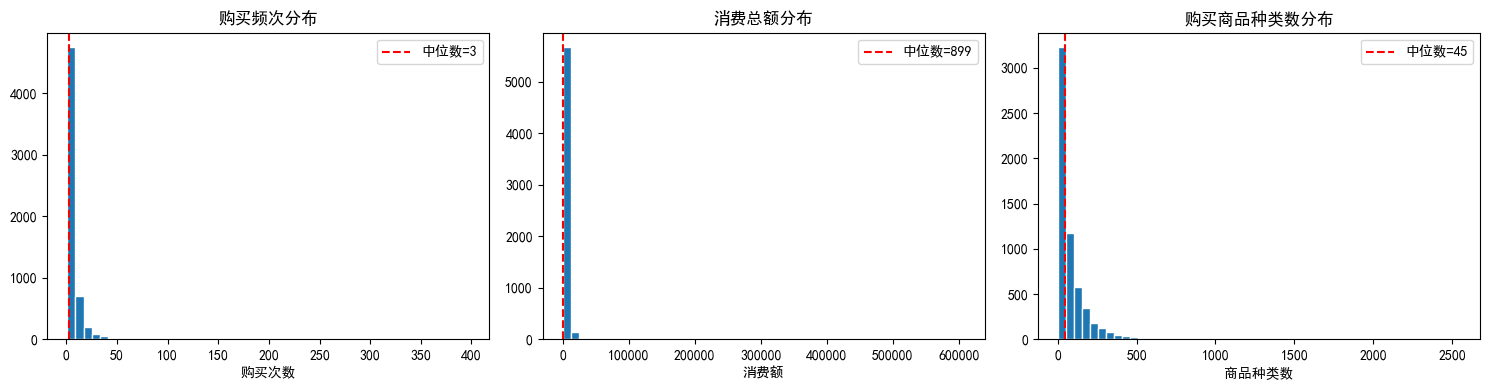

            总消费    购买次数   购买商品数
count    5878.0  5878.0  5878.0
mean     3018.6     6.3    82.0
std     14737.7    13.0   116.5
min         3.0     1.0     1.0
25%       348.8     1.0    19.0
50%       898.9     3.0    45.0
75%      2307.1     7.0   103.0
max    608821.6   398.0  2550.0


In [5]:
customer = df.groupby("Customer ID").agg(
    总消费=("Revenue", "sum"),
    购买次数=("Invoice", "nunique"),
    购买商品数=("StockCode", "nunique")
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(customer["购买次数"], bins=50, edgecolor="white")
axes[0].set_title("购买频次分布")
axes[0].set_xlabel("购买次数")
axes[0].axvline(customer["购买次数"].median(), color="red", linestyle="--", label=f'中位数={customer["购买次数"].median():.0f}')
axes[0].legend()

axes[1].hist(customer["总消费"], bins=50, edgecolor="white")
axes[1].set_title("消费总额分布")
axes[1].set_xlabel("消费额")
axes[1].axvline(customer["总消费"].median(), color="red", linestyle="--", label=f'中位数={customer["总消费"].median():.0f}')
axes[1].legend()

axes[2].hist(customer["购买商品数"], bins=50, edgecolor="white")
axes[2].set_title("购买商品种类数分布")
axes[2].set_xlabel("商品种类数")
axes[2].axvline(customer["购买商品数"].median(), color="red", linestyle="--", label=f'中位数={customer["购买商品数"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(customer.describe().round(1))

## 发现：典型的幂律分布
- 50% 的用户只买了 3 次或更少，消费不到 899 英镑
- 但最高的用户消费了 60 万+，均值（3,019）是中位数（899）的 3.4 倍
- 说明少数高价值客户贡献了大量收入，非常适合用 RFM 做分层运营
- **产品启示**：不能用"平均用户"来设计产品策略，必须分层对待

## EDA 关键结论

1. **季节性强**：Q4 是销售旺季（圣诞采购），运营节奏要跟着走
2. **市场集中**：英国占 83%，海外扩张是潜在增长点
3. **商品长尾**：20% 商品贡献 78% 收入，推荐策略应聚焦头部
4. **用户分化严重**：幂律分布明显，必须分层运营

→ 下一步：用 RFM 模型对 5,878 个客户进行分层